# Cluster-y cross-correlation

In [1]:
%matplotlib inline
import json
import sys
import time
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import yaml

HERE = Path.cwd()
if HERE.name != 'DES_cluster':
    HERE = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/DES_cluster')
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))
import redmapper_y_cross as cross

CONFIG = HERE / 'params_redmapper_y_cross_z0p4_0p6_thetaejx1p5.yaml'

{
  "claim_boundary": "diagnostic only; ACT BUNIT/beam metadata absent; no fitted amplitude or goodness claim",
  "comparison_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_sim_data_comparison_z0p4_0p6_thetaejx1p5.png",
  "data_central_mean": 5.919983793614895e-07,
  "data_clusters": 4674,
  "data_null_pte": 0.8269368451182195,
  "data_random_ratio": 10,
  "data_resolution": {
    "control_downsample_factor": 2,
    "max_shift_sigma": 0.559654036764165,
    "median_shift_sigma": 0.056251637254891525,
    "pass": false,
    "science_downsample_factor": 1
  },
  "diagnostics_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_selection_random_diagnostics_z0p4_0p6_thetaejx1p5.png",
  "elapsed_seconds": 416.9013124679914,
  "input_hashes_unchanged": true,
  "result_hdf5": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/redmapper_y_cross/redmapper_y_sim_data_comparison_z0p4_0p6_thetaejx1

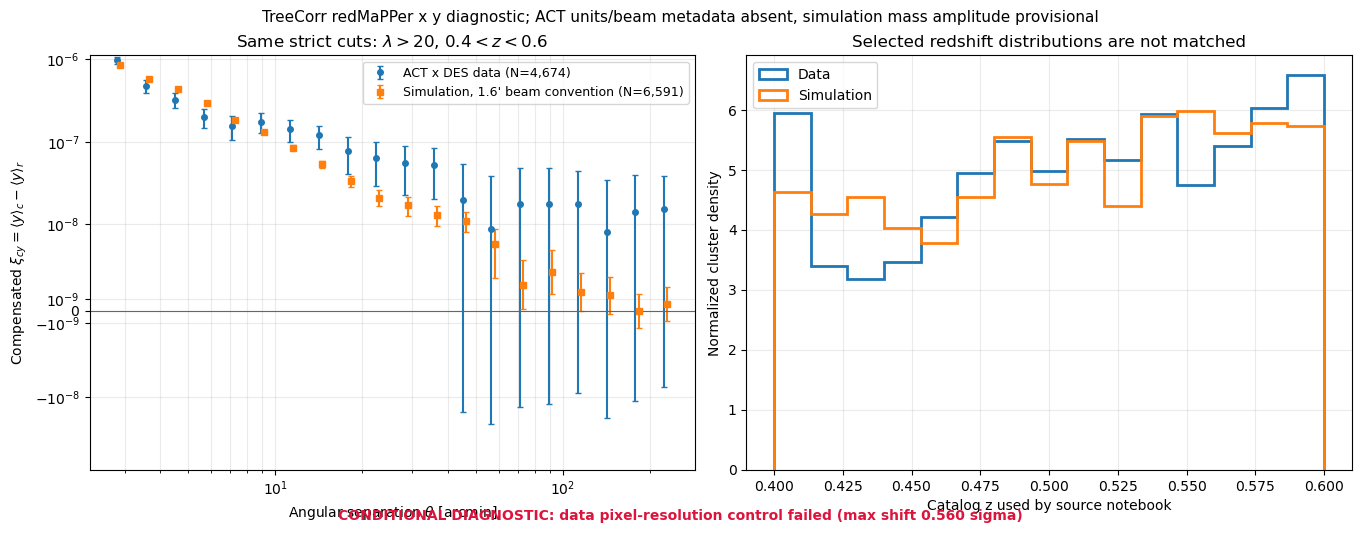

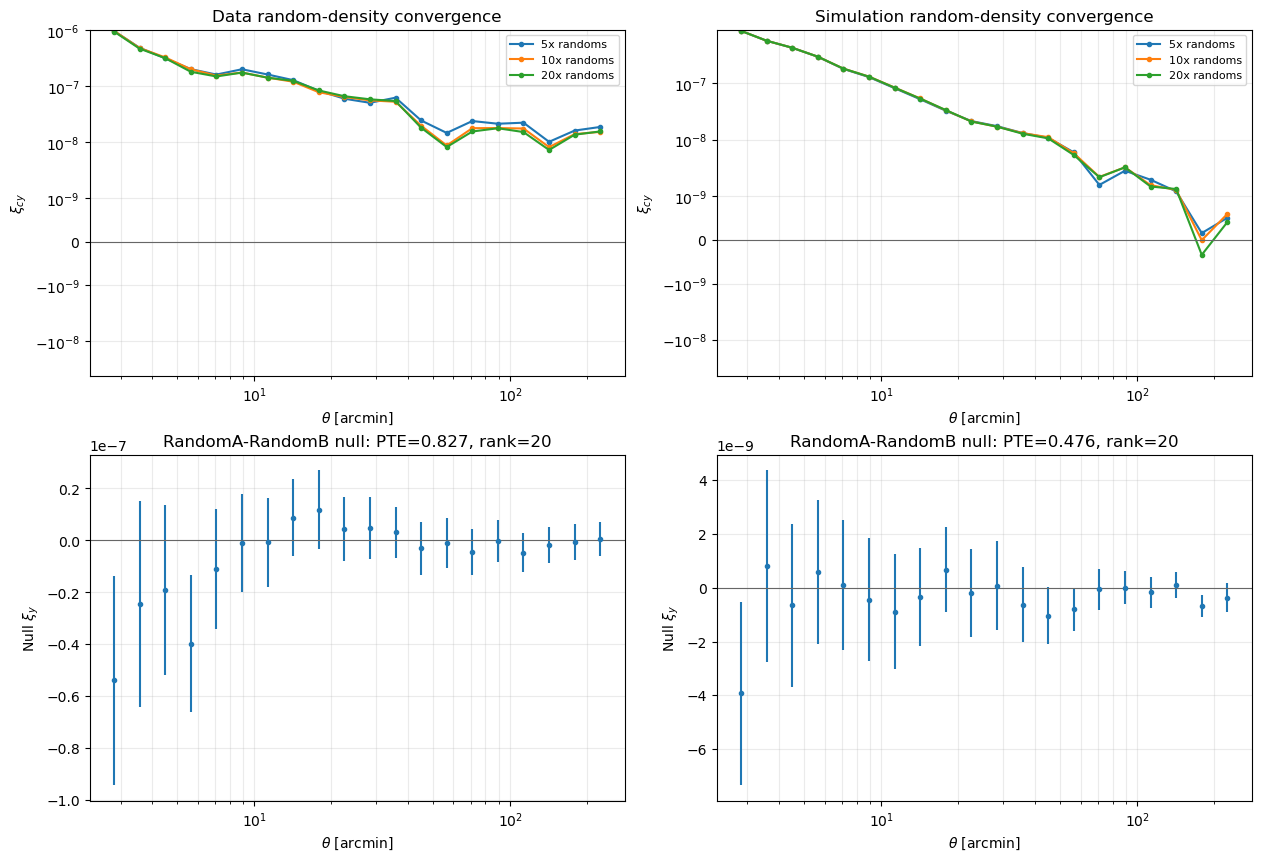

In [2]:
started = time.perf_counter()
analysis = cross.run_analysis(CONFIG)
elapsed_seconds = time.perf_counter() - started
print(json.dumps({**analysis['summary'], 'elapsed_seconds': elapsed_seconds}, indent=2, sort_keys=True))

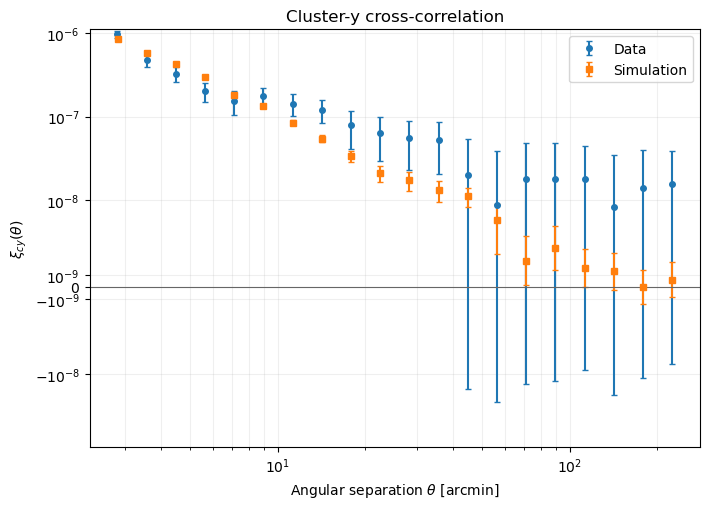

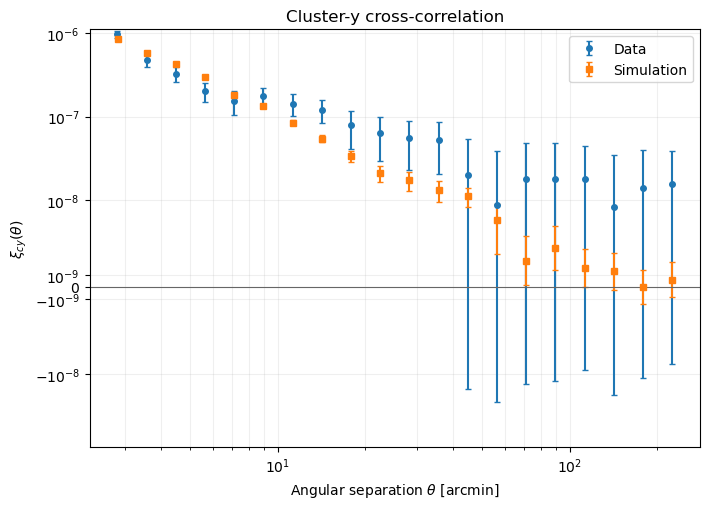

In [3]:
plt.close(analysis['comparison_figure'])
plt.close(analysis['diagnostics_figure'])
fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.errorbar(analysis['data']['theta_arcmin'], analysis['data']['xi'], yerr=analysis['data']['error'], fmt='o', ms=4, capsize=2, label='Data')
ax.errorbar(analysis['simulation']['theta_arcmin'], analysis['simulation']['xi'], yerr=analysis['simulation']['error'], fmt='s', ms=4, capsize=2, label='Simulation')
values = np.concatenate([analysis['data']['xi'], analysis['simulation']['xi']])
nonzero = np.abs(values[values != 0.0])
ax.set_xscale('log')
ax.set_yscale('symlog', linthresh=max(float(np.percentile(nonzero, 15)), 1.0e-14), linscale=0.7)
ax.axhline(0.0, color='0.4', lw=0.8)
ax.set_xlabel(r'Angular separation $\theta$ [arcmin]')
ax.set_ylabel(r'$\xi_{cy}(\theta)$')
ax.set_title('Cluster-y cross-correlation')
ax.legend()
ax.grid(True, which='both', alpha=0.2)
fig.tight_layout()
fig.savefig(analysis['comparison_path'], dpi=170, bbox_inches='tight')
display(fig)

In [4]:
with h5py.File(analysis['config']['simulation']['ymap_hdf5'], 'r') as yhandle:
    ycfg = yaml.safe_load(yhandle.attrs['config_yaml'])
    ymap_checks = {
        'theta_ej_0': float(ycfg['profiles']['overrides']['sim_params']['theta_ej_0']),
        'config_sha256': yhandle.attrs['config_sha256'],
        'complete': bool(yhandle.attrs['complete_selected_catalog_painted']),
        'n_halos': int(yhandle.attrs['n_halos_painted']),
    }
with h5py.File(analysis['summary']['result_hdf5'], 'r') as handle:
    saved = {
        'selection': handle.attrs['selection'],
        'validation_status': handle.attrs['validation_status'],
        'simulation_rows': json.loads(handle['simulation'].attrs['cluster_metadata_json'])['selected_rows'],
        'data_rows': json.loads(handle['data'].attrs['cluster_metadata_json'])['selected_rows'],
    }
checks = {
    'theta_ej_0_is_3': ymap_checks['theta_ej_0'] == 3.0,
    'ymap_config_identity': ymap_checks['config_sha256'] == 'baebbe49318908b42ab3b7f7f56844aac962a09c6af224b1d883a5cded6bcd14',
    'complete_ymap': ymap_checks['complete'] and ymap_checks['n_halos'] == 1299336,
    'strict_selection': saved['selection'] == 'lambda > 20 and 0.4 < z < 0.6 (strict; z column)',
    'finite_profiles': bool(np.isfinite(analysis['simulation']['xi']).all() and np.isfinite(analysis['data']['xi']).all()),
    'positive_centers': analysis['summary']['simulation_central_mean'] > 0.0 and analysis['summary']['data_central_mean'] > 0.0,
    'expected_rows': saved['simulation_rows'] == 6591 and saved['data_rows'] == 4674,
    'resolution_status_preserved': saved['validation_status'] == 'refuted_data_resolution',
}
assert all(checks.values()), checks
print(json.dumps({'checks': checks, 'ymap': ymap_checks, 'measurement': saved}, indent=2, sort_keys=True))

{
  "checks": {
    "complete_ymap": true,
    "expected_rows": true,
    "finite_profiles": true,
    "positive_centers": true,
    "resolution_status_preserved": true,
    "strict_selection": true,
    "theta_ej_0_is_3": true,
    "ymap_config_identity": true
  },
  "measurement": {
    "data_rows": 4674,
    "selection": "lambda > 20 and 0.4 < z < 0.6 (strict; z column)",
    "simulation_rows": 6591,
    "validation_status": "refuted_data_resolution"
  },
  "ymap": {
    "complete": true,
    "config_sha256": "baebbe49318908b42ab3b7f7f56844aac962a09c6af224b1d883a5cded6bcd14",
    "n_halos": 1299336,
    "theta_ej_0": 3.0
  }
}
